### Install Packages

In [1]:
# Data Processing
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Outlier Detection
from scipy import stats

# Class Imbalance
from imblearn.over_sampling import RandomOverSampler

# Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Hyperparameter Tuning
from sklearn.model_selection import RandomizedSearchCV

# Save Model
import joblib
import pickle

import warnings
warnings.filterwarnings("ignore")

ModuleNotFoundError: No module named 'imblearn'

### Data Collection

In [ ]:
df = pd.read_csv("cover_type.csv")
print(df.head())

   Elevation  Aspect  Slope  Horizontal_Distance_To_Hydrology  \
0       2596      51      3                               258   
1       2590      56      2                               212   
2       2804     139      9                               268   
3       2785     155     18                               242   
4       2595      45      2                               153   

   Vertical_Distance_To_Hydrology  Horizontal_Distance_To_Roadways  \
0                               0                              510   
1                              -6                              390   
2                              65                             3180   
3                             118                             3090   
4                              -1                              391   

   Hillshade_9am  Hillshade_Noon  Hillshade_3pm  \
0            221             232            148   
1            220             235            151   
2            234             238   

### Data Understanding

In [ ]:
print(df.shape)

(145890, 13)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145890 entries, 0 to 145889
Data columns (total 13 columns):
 #   Column                              Non-Null Count   Dtype 
---  ------                              --------------   ----- 
 0   Elevation                           145890 non-null  int64 
 1   Aspect                              145890 non-null  int64 
 2   Slope                               145890 non-null  int64 
 3   Horizontal_Distance_To_Hydrology    145890 non-null  int64 
 4   Vertical_Distance_To_Hydrology      145890 non-null  int64 
 5   Horizontal_Distance_To_Roadways     145890 non-null  int64 
 6   Hillshade_9am                       145890 non-null  int64 
 7   Hillshade_Noon                      145890 non-null  int64 
 8   Hillshade_3pm                       145890 non-null  int64 
 9   Horizontal_Distance_To_Fire_Points  145890 non-null  int64 
 10  Cover_Type                          145890 non-null  object
 11  Wilderness_Area                     145

In [ ]:
df.describe()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area,Soil_Type
count,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000
mean,2874.458949,141.127418,11.925574,251.824738,34.554322,3313.827541,217.368106,224.874748,139.788203,3044.958105,1.186593,23.364905
std,210.801279,107.719296,6.319326,192.473899,41.215776,1687.779953,21.590298,16.084851,31.311690,1761.882341,0.656571,8.215184
min,1863.000000,0.000000,0.000000,0.000000,-146.000000,0.000000,0.000000,99.000000,0.000000,0.000000,1.000000,1.000000
25%,2747.000000,54.000000,7.000000,95.000000,7.000000,1848.000000,207.000000,216.000000,121.000000,1608.000000,1.000000,12.000000
50%,2909.000000,108.000000,11.000000,212.000000,23.000000,3420.000000,222.000000,226.000000,140.000000,2713.000000,1.000000,29.000000
75%,3004.000000,217.000000,15.000000,362.000000,51.000000,4673.000000,232.000000,236.000000,159.000000,4478.000000,1.000000,29.000000
max,3849.000000,360.000000,61.000000,1343.000000,554.000000,7117.000000,254.000000,254.000000,248.000000,7173.000000,4.000000,40.000000


In [ ]:
print(df["Cover_Type"].value_counts()) # Target Distribution
print(df.isnull().sum()) # Missing Value Handling.

Cover_Type
Lodgepole Pine       103071
Spruce/Fir            31110
Aspen                  3069
Krummholz              2160
Ponderosa Pine         2160
Douglas-fir            2160
Cottonwood/Willow      2160
Name: count, dtype: int64
Elevation                             0
Aspect                                0
Slope                                 0
Horizontal_Distance_To_Hydrology      0
Vertical_Distance_To_Hydrology        0
Horizontal_Distance_To_Roadways       0
Hillshade_9am                         0
Hillshade_Noon                        0
Hillshade_3pm                         0
Horizontal_Distance_To_Fire_Points    0
Cover_Type                            0
Wilderness_Area                       0
Soil_Type                             0
dtype: int64


In [ ]:
df.duplicated().sum ()

np.int64(0)

In [ ]:
# Check missing values
print(df.isnull().sum())

# Fill numeric NaNs with median
df.fillna(df.mode(), inplace=True)

Elevation                             0
Aspect                                0
Slope                                 0
Horizontal_Distance_To_Hydrology      0
Vertical_Distance_To_Hydrology        0
Horizontal_Distance_To_Roadways       0
Hillshade_9am                         0
Hillshade_Noon                        0
Hillshade_3pm                         0
Horizontal_Distance_To_Fire_Points    0
Cover_Type                            0
Wilderness_Area                       0
Soil_Type                             0
dtype: int64


In [ ]:
df['Cover_Type'].value_counts()

,count
Cover_Type,
Lodgepole Pine,103071
Spruce/Fir,31110
Aspen,3069
Krummholz,2160
Ponderosa Pine,2160
Douglas-fir,2160
Cottonwood/Willow,2160


### Data Cleaning & Transformation

In [ ]:
#Categorical Feature
cat_cols = df.select_dtypes(include="object").columns
for col in cat_cols:
	df[col].fillna(df[col].mode()[0], inplace=True)

df[cat_cols].value_counts()

,count
Cover_Type,
Lodgepole Pine,103071
Spruce/Fir,31110
Aspen,3069
Douglas-fir,2160
Cottonwood/Willow,2160
Krummholz,2160
Ponderosa Pine,2160


In [ ]:
X = df.drop('Cover_Type', axis=1)
y = df['Cover_Type']

print(X), print(y)

        Elevation  Aspect  Slope  Horizontal_Distance_To_Hydrology  \
0            2596      51      3                               258   
1            2590      56      2                               212   
2            2804     139      9                               268   
3            2785     155     18                               242   
4            2595      45      2                               153   
...           ...     ...    ...                               ...   
145885       2834      88      8                               376   
145886       2832      68      4                               390   
145887       2829      80      7                               390   
145888       2826     121      7                               379   
145889       2823     132     12                               371   

        Vertical_Distance_To_Hydrology  Horizontal_Distance_To_Roadways  \
0                                    0                              510   
1        

(None, None)

### Class Imbalance Handling

In [ ]:
# Class Balancing
from imblearn.over_sampling import RandomOverSampler

X = df.drop('Cover_Type', axis=1)
y = df['Cover_Type']

#Handle Class Imbalance
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X, y)

# Check new distribution
print(X_resampled)
print(pd.Series(y_resampled).value_counts())

        Elevation  Aspect  Slope  Horizontal_Distance_To_Hydrology  \
0            2596      51      3                               258   
1            2590      56      2                               212   
2            2804     139      9                               268   
3            2785     155     18                               242   
4            2595      45      2                               153   
...           ...     ...    ...                               ...   
721492       2909     256      4                               270   
721493       2771     146      7                               216   
721494       2982      74     16                               301   
721495       2982      68      9                               319   
721496       2829     289      9                               153   

        Vertical_Distance_To_Hydrology  Horizontal_Distance_To_Roadways  \
0                                    0                              510   
1        

### Handle outliers using IQR or Z-Score method

In [ ]:
#Z-Score method
# numeric_columns = df.select_dtypes(include=np.number).columns

# z_scores = np.abs(stats.zscore(df[numeric_columns]))

# df = df[(z_scores < 3).all(axis=1)]

In [ ]:
#IQR
numeric_columns = df.select_dtypes(include=np.number).columns
for col in numeric_columns:

  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)

  IQR = Q3 - Q1

  lower = Q1 - 1.5 * IQR
  upper = Q3 + 1.5 * IQR

  df = df[(df[col] >= lower) & (df[col] <= upper)]

In [ ]:
#Skewness
# print(df[numeric_columns].skew())

In [ ]:
#Log Transformation
# for col in numeric_columns:

#   if abs(df[col].skew()) > 1:

#       df[col] = np.log1p(df[col])

### Log Transformation - Highly Skewed to make distribution normal

In [ ]:
#Skewness
skewed_features = X_resampled.skew().sort_values(ascending=False)
print(skewed_features)

Vertical_Distance_To_Hydrology        1.627380
Horizontal_Distance_To_Hydrology      1.494882
Horizontal_Distance_To_Fire_Points    1.284483
Horizontal_Distance_To_Roadways       0.853418
Slope                                 0.611988
Aspect                                0.543614
Elevation                             0.155939
Soil_Type                             0.154159
Wilderness_Area                      -0.116676
Hillshade_3pm                        -0.343107
Hillshade_Noon                       -1.017184
Hillshade_9am                        -1.183733
dtype: float64


In [ ]:
import numpy as np
print(skewed_features[skewed_features > 1])
print(skewed_features[skewed_features > 1].index.tolist())
print(skewed_features[skewed_features < -1])
print(skewed_features[skewed_features < -1].index.tolist())

Vertical_Distance_To_Hydrology        1.627380
Horizontal_Distance_To_Hydrology      1.494882
Horizontal_Distance_To_Fire_Points    1.284483
dtype: float64
['Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Hydrology', 'Horizontal_Distance_To_Fire_Points']
Hillshade_Noon   -1.017184
Hillshade_9am    -1.183733
dtype: float64
['Hillshade_Noon', 'Hillshade_9am']


In [ ]:
#Log Transformation
import numpy as np

rs_to_transform = skewed_features[skewed_features > 1].index.tolist()
for col in rs_to_transform:
    X_resampled[col] = np.log1p(X_resampled[col])

# left_skewed_cols = skewed_features[skewed_features < -1].index.tolist()

# for col in left_skewed_cols:
#     max_value = X_resampled[col].max()

#     X_resampled[col] = np.log1p(max_value - X_resampled[col])

In [ ]:
l = X_resampled.skew().sort_values(ascending=False)
print(l)

Horizontal_Distance_To_Roadways       0.853418
Slope                                 0.611988
Aspect                                0.543614
Elevation                             0.155939
Soil_Type                             0.154159
Wilderness_Area                      -0.116676
Hillshade_3pm                        -0.343107
Horizontal_Distance_To_Fire_Points   -0.490315
Hillshade_Noon                       -1.017184
Hillshade_9am                        -1.183733
Horizontal_Distance_To_Hydrology     -1.571728
Vertical_Distance_To_Hydrology             NaN
dtype: float64


In [ ]:
print(X_resampled['Vertical_Distance_To_Hydrology'].isnull().sum().sum())

46842


In [ ]:
# Check for NaNs and Infs
print(np.isinf(X_resampled).sum().sum())   # total infinities
print(X_resampled.isnull().sum().sum())   # total NaNs

5547
46842


In [ ]:
X_resampled.replace([np.inf, -np.inf], np.nan, inplace=True)
X_resampled.fillna(X_resampled.median(), inplace=True)

###  Zero Variance Feature Detection.

In [ ]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.0)
selector.fit(X_resampled)

# Get columns to drop (if any column having with high variant (constant value))
# For us there is no high variant column to remove/drop.
zero_variance_cols = X_resampled.columns[~selector.get_support()]
print(zero_variance_cols)

Index([], dtype='object')


In [ ]:
X_resampled.drop(columns=zero_variance_cols, inplace=True)

In [ ]:
X_resampled.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area,Soil_Type
0,2596,51,3,5.556828,0.000000,510,221,232,148,8.745125,1,29
1,2590,56,2,5.361292,3.496508,390,220,235,151,8.736489,1,29
2,2804,139,9,5.594711,4.189655,3180,234,238,135,8.719644,1,12
3,2785,155,18,5.493061,4.779123,3090,238,238,122,8.734238,1,30
4,2595,45,2,5.036953,3.496508,391,220,234,150,8.727940,1,29


In [ ]:
print(df.shape)

(119955, 13)


In [ ]:
print(X_resampled.shape)

(721497, 12)


In [ ]:
print(y_resampled.shape)

(721497,)


### Cover_Type (target) convert from text values into numeric values for ML to understand

In [ ]:
y_resampled

,Cover_Type
0,Aspen
1,Aspen
2,Lodgepole Pine
3,Lodgepole Pine
4,Aspen
...,...
721492,Spruce/Fir
721493,Spruce/Fir
721494,Spruce/Fir
721495,Spruce/Fir


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Label Encoder - Target column
# Encode target labels to start from 0
le = LabelEncoder()
y_resampled = le.fit_transform(y_resampled)

In [ ]:
y_resampled

array([0, 0, 4, ..., 6, 6, 6])

### Encoder saved as pickle

In [ ]:
import pickle
with open("encoder.pkl", "wb") as f:
    pickle.dump(le, f)

### Feature Engineering:

In [ ]:
#We need to check the skewness of Dataset Features
skewed_features = X_resampled.skew().sort_values(ascending=False)
print(skewed_features)

Horizontal_Distance_To_Roadways       0.853418
Slope                                 0.611988
Aspect                                0.543614
Elevation                             0.155939
Soil_Type                             0.154159
Wilderness_Area                      -0.116676
Hillshade_3pm                        -0.343107
Horizontal_Distance_To_Fire_Points   -0.490315
Vertical_Distance_To_Hydrology       -0.796334
Hillshade_Noon                       -1.017184
Hillshade_9am                        -1.183733
Horizontal_Distance_To_Hydrology     -1.571728
dtype: float64


In [ ]:
#Skewness > 1 then we can apply log transformation
print(df["Elevation"].skew())

-0.14463864903762194


In [ ]:
df["Slope"].skew()

np.float64(0.31681656840378664)

In [ ]:
#Skewness > 1 then we can apply log transformation
df["Horizontal_Distance_To_Roadways"].skew()

np.float64(-0.0955377427430026)

In [ ]:
# Water source is a 2D distance.
# Distance² = Horizontal² + Vertical²
# if("Horizontal_Distance_To_Hydrology" in df.columns
#    and "Vertical_Distance_To_Hydrology" in df.columns):

# 		df["Hydrology_Distance"] = np.sqrt(
# 			df["Horizontal_Distance_To_Hydrology"]**2 + df["Vertical_Distance_To_Hydrology"]**2
# 		)

In [ ]:
# Amount of sunlight at different times 0 to 255.
# 9am = 200, Noon = 220 and 3pm = 180
# df["Average_Hillshade"] = (
#     df["Hillshade_9am"] + df["Hillshade_Noon"] + df["Hillshade_3pm"]
# )/3

In [ ]:
df.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Cover_Type,Wilderness_Area,Soil_Type
0,2596,51,3,258,0,510,221,232,148,6279,Aspen,1,29
1,2590,56,2,212,-6,390,220,235,151,6225,Aspen,1,29
2,2804,139,9,268,65,3180,234,238,135,6121,Lodgepole Pine,1,12
4,2595,45,2,153,-1,391,220,234,150,6172,Aspen,1,29
5,2579,132,6,300,-15,67,230,237,140,6031,Lodgepole Pine,1,29


In [ ]:
#Encode Feature
feature_encoders = {}

for col in cat_cols:

  if col != "Cover_Type":

    le = LabelEncoder()

    df[col] = le.fit_transform(df[col])

    feature_encoders[col] = le


In [ ]:
#Save encoders
# joblib.dump(feature_encoders, "feature_encoders.pkl")
# import pickle
# with open("feature_encoders.pkl", "wb") as f:
#     pickle.dump(le, f)

In [ ]:
#Encode Target Column
target_encoder = LabelEncoder()

df["Cover_Type"] = target_encoder.fit_transform(
  df["Cover_Type"]
)

joblib.dump(target_encoder, "target_encoder.pkl")

#Split Feature and Target
X = df.drop("Cover_Type", axis=1)

y = df["Cover_Type"]

### Exploratory Data Analysis (EDA)

In [ ]:
df.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Cover_Type,Wilderness_Area,Soil_Type
0,2596,51,3,258,0,510,221,232,148,6279,0,1,29
1,2590,56,2,212,-6,390,220,235,151,6225,0,1,29
2,2804,139,9,268,65,3180,234,238,135,6121,2,1,12
4,2595,45,2,153,-1,391,220,234,150,6172,0,1,29
5,2579,132,6,300,-15,67,230,237,140,6031,2,1,29


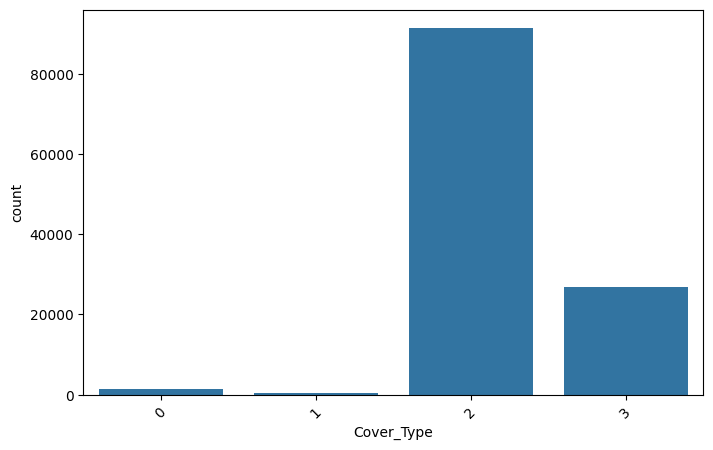

In [ ]:
# Target Distribution
plt.figure(figsize=(8,5))
sns.countplot(x='Cover_Type', data=df)
plt.xticks(rotation=45)
plt.show()

In [ ]:
numeric_columns = df.select_dtypes(exclude=['object'])
numeric_columns

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Cover_Type,Wilderness_Area,Soil_Type
0,2596,51,3,258,0,510,221,232,148,6279,0,1,29
1,2590,56,2,212,-6,390,220,235,151,6225,0,1,29
2,2804,139,9,268,65,3180,234,238,135,6121,2,1,12
4,2595,45,2,153,-1,391,220,234,150,6172,0,1,29
5,2579,132,6,300,-15,67,230,237,140,6031,2,1,29
...,...,...,...,...,...,...,...,...,...,...,...,...,...
145885,2834,88,8,376,44,2552,232,227,128,1595,2,1,29
145886,2832,68,4,390,44,2522,224,231,142,1572,2,1,29
145887,2829,80,7,390,33,2492,229,228,133,1550,2,1,29
145888,2826,121,7,379,30,2462,232,234,135,1528,2,1,29


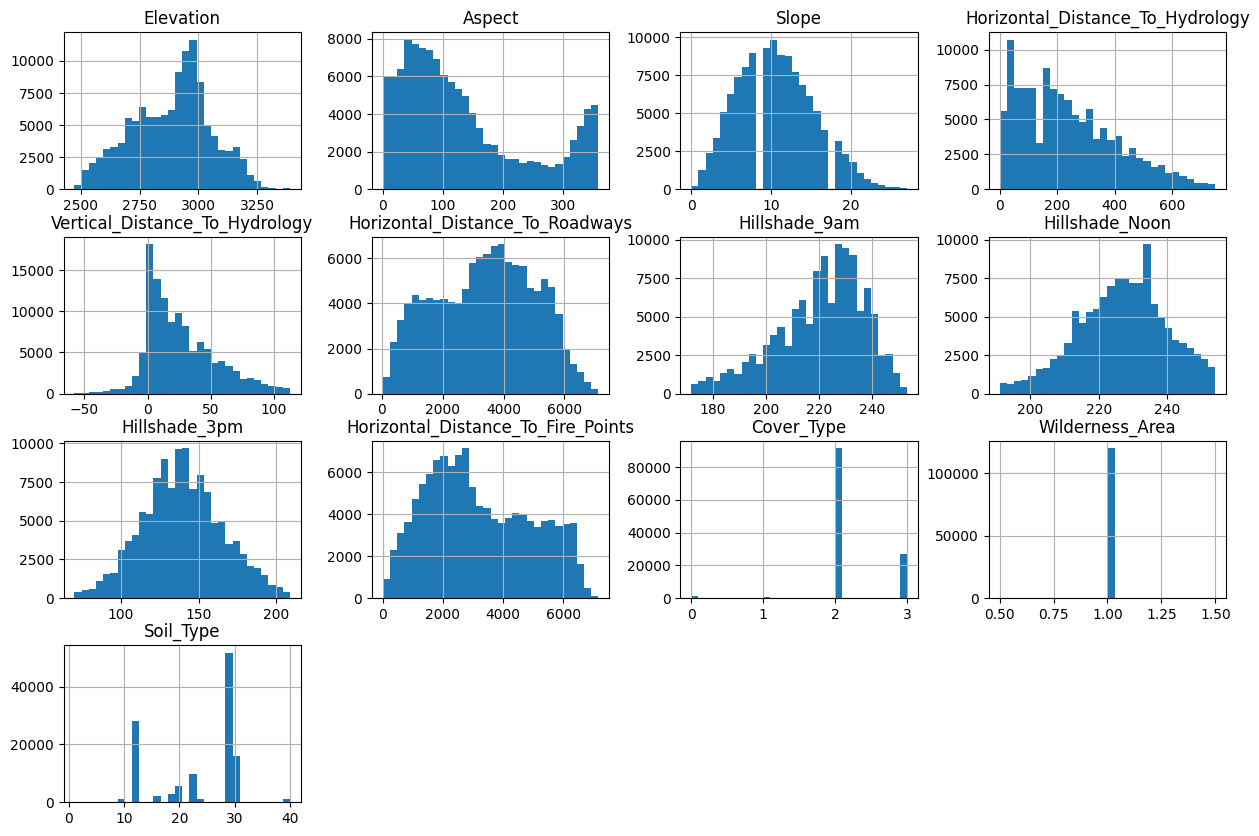

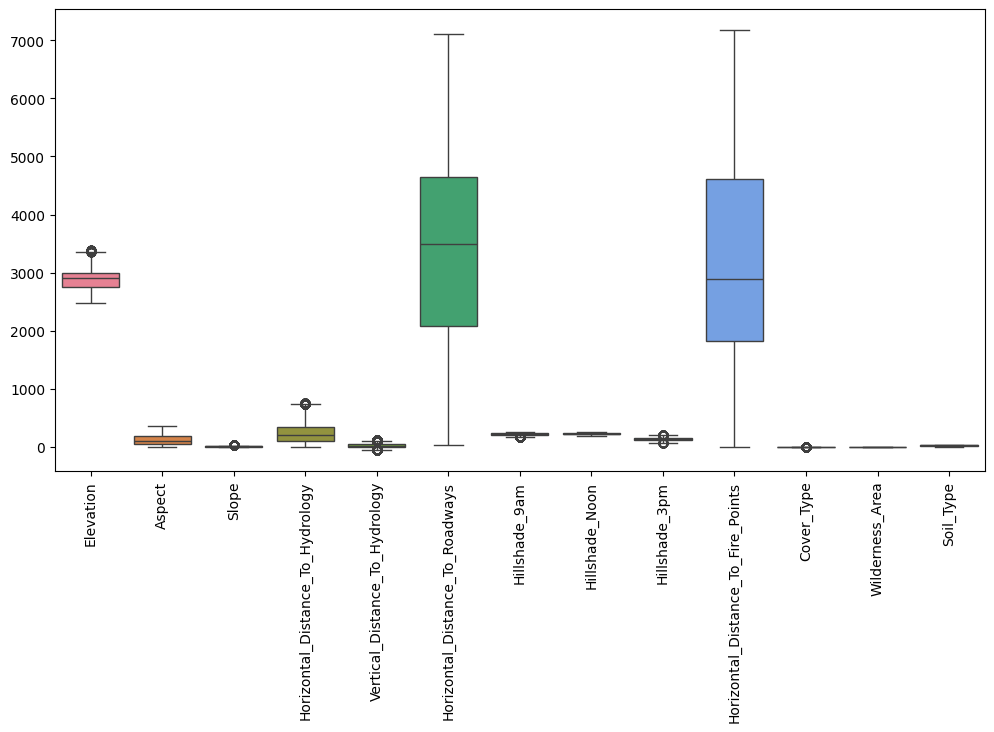

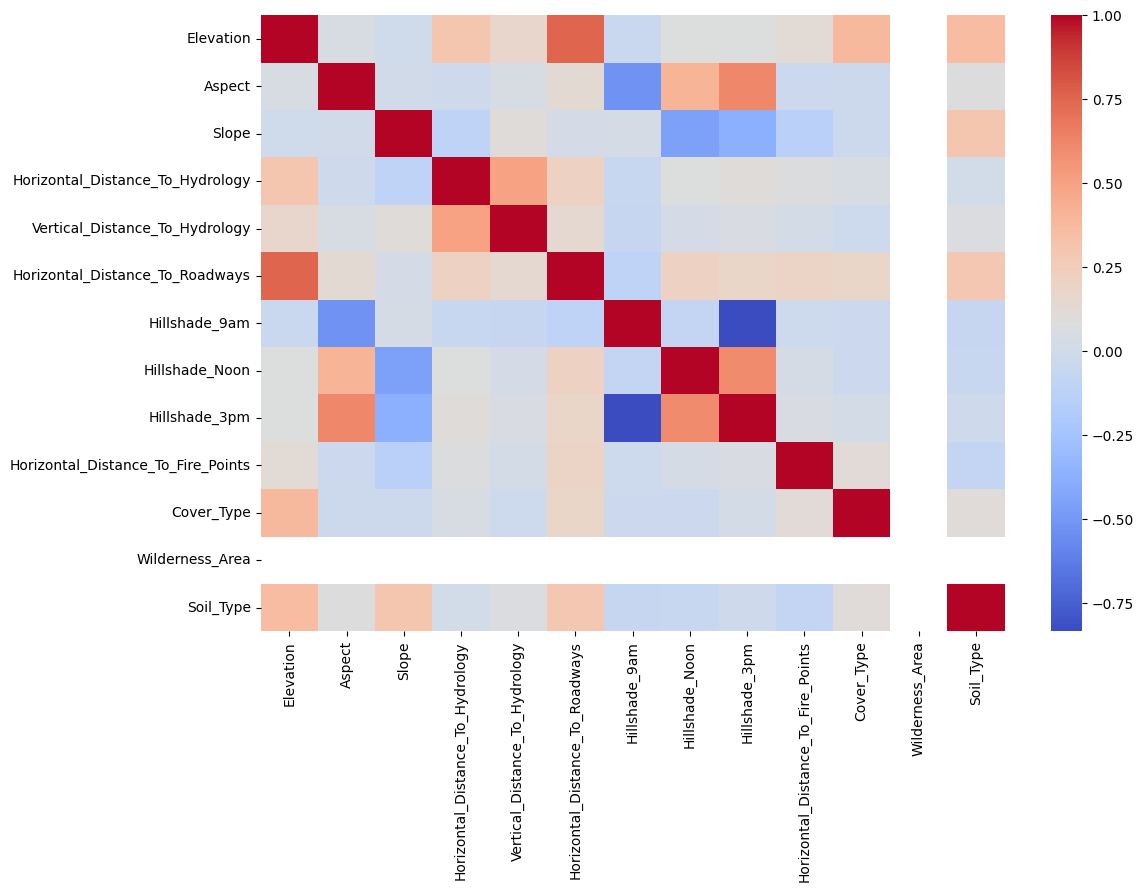

In [ ]:
numeric_columns = df.select_dtypes(exclude=['object'])

# Histograms, boxplots and heatmap.
df.hist(figsize=(15,10),bins=30)
plt.show()

plt.figure(figsize=(12,6))
sns.boxplot(data=numeric_columns)
plt.xticks(rotation=90)
plt.show()

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True),cmap='coolwarm')
plt.show()

### Class imbalance handling

In [ ]:
#Handle Class Imbalance
# Class Balancing
from imblearn.over_sampling import RandomOverSampler

X = df.drop('Cover_Type', axis=1)
y = df['Cover_Type']

#Handle Class Imbalance
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X, y)

# Check new distribution
print(X_resampled)
print(pd.Series(y_resampled).value_counts())

        Elevation  Aspect  Slope  Horizontal_Distance_To_Hydrology  \
0            2596      51      3                               258   
1            2590      56      2                               212   
2            2804     139      9                               268   
3            2595      45      2                               153   
4            2579     132      6                               300   
...           ...     ...    ...                               ...   
366075       3196      63     13                               404   
366076       3165      24      9                               618   
366077       3176      59     13                               404   
366078       2690     352      3                               127   
366079       2975      79      8                               150   

        Vertical_Distance_To_Hydrology  Horizontal_Distance_To_Roadways  \
0                                    0                              510   
1        

In [ ]:
y_resampled.head()

,Cover_Type
0,0
1,0
2,2
3,0
4,2


<Axes: >

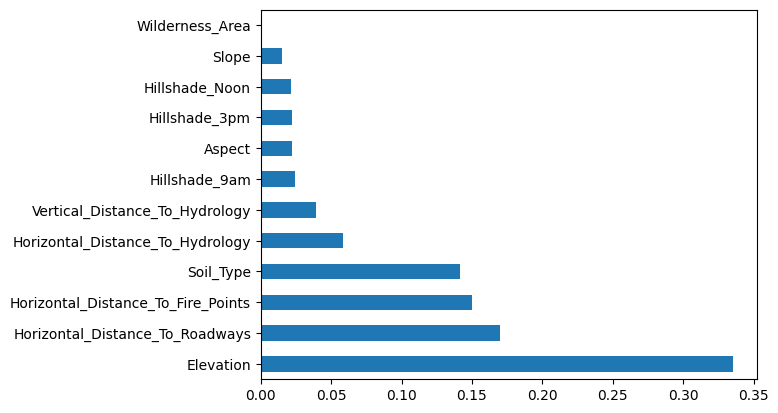

In [ ]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.3, random_state=42, stratify=y_resampled)

#Baseline Random Forest
# This will consider Majority 'vote' to identify a tree species.
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Feature Importance
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=False).head(15).plot(kind='barh')

In [ ]:
print(importances)

Elevation                             0.335512
Aspect                                0.022316
Slope                                 0.015030
Horizontal_Distance_To_Hydrology      0.058328
Vertical_Distance_To_Hydrology        0.039064
Horizontal_Distance_To_Roadways       0.170160
Hillshade_9am                         0.024660
Hillshade_Noon                        0.021544
Hillshade_3pm                         0.021953
Horizontal_Distance_To_Fire_Points    0.150106
Wilderness_Area                       0.000000
Soil_Type                             0.141327
dtype: float64


In [ ]:
#Feature Imbalance
importance_df = pd.DataFrame({
  "Feature": X_train.columns,
  "Importance":rf.feature_importances_

}).sort_values(by="Importance", ascending=False)

print(importance_df)

                               Feature  Importance
0                            Elevation    0.335512
5      Horizontal_Distance_To_Roadways    0.170160
9   Horizontal_Distance_To_Fire_Points    0.150106
11                           Soil_Type    0.141327
3     Horizontal_Distance_To_Hydrology    0.058328
4       Vertical_Distance_To_Hydrology    0.039064
6                        Hillshade_9am    0.024660
1                               Aspect    0.022316
8                        Hillshade_3pm    0.021953
7                       Hillshade_Noon    0.021544
2                                Slope    0.015030
10                     Wilderness_Area    0.000000


In [ ]:
top_10_features = importances.head(10).index.tolist()
print(top_10_features)

['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways', 'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm', 'Horizontal_Distance_To_Fire_Points']


In [ ]:
X_train_top10 = X_train[top_10_features]
X_test_top10 = X_test[top_10_features]

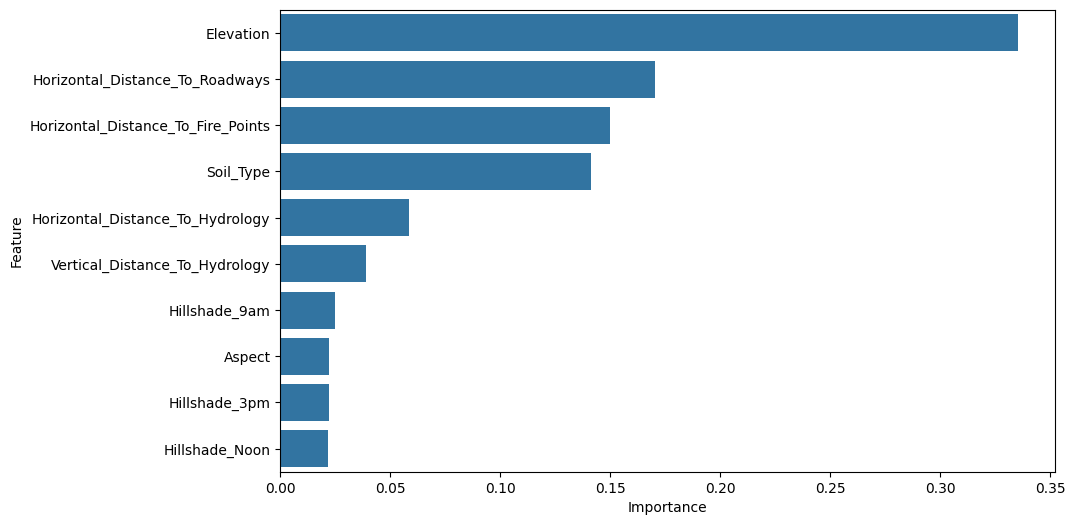

In [ ]:
#Plot Importance
plt.figure(figsize=(10,6))

sns.barplot(x="Importance", y="Feature", data=importance_df.head(10))

plt.show()

In [ ]:
# #Select Top Feature
# top_features = importance_df.head(10)["Feature"]

# X_train = X_train[top_features]

# X_test = X_test[top_features]

In [ ]:
rf_top10 = RandomForestClassifier(random_state=42)
rf_top10.fit(X_train_top10, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
# y_pred_top10 = rf_top10.predict(X_test_top10)

In [ ]:
# from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# y_pred_top10 = rf_top10.predict(X_test_top10)

# print("Accuracy:", accuracy_score(y_test, y_pred_top10))
# print(classification_report(y_test, y_pred_top10))
# print(confusion_matrix(y_test, y_pred_top10))

### Model Building

In [ ]:
#Train 5 Models
models = {
  "Random Forest": RandomForestClassifier(),
  "Decision Tree": DecisionTreeClassifier(),
  "Logistic Regression": LogisticRegression(max_iter=5000),
  "KNN": KNeighborsClassifier(),
  "XGBoost": XGBClassifier(eval_metric='mlogloss')
}

In [ ]:
#Evaluate Models
results = {}

for name, model in models.items():

  model.fit(X_train, y_train)

  pred = model.predict(X_test)

  accuracy = accuracy_score(y_test,pred)

  results[name] = accuracy
  print("\n")
  print("="*50)
  print(name)
  print("="*50)

  print(f"Accuracy:{accuracy:.4f}")

  print(confusion_matrix(y_test, pred))

  print(classification_report(y_test, pred)
  )



Random Forest
Accuracy:0.9922
[[27456     0     0     0]
 [    0 27456     0     0]
 [   32     0 26774   650]
 [    3     0   167 27286]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     27456
           1       1.00      1.00      1.00     27456
           2       0.99      0.98      0.98     27456
           3       0.98      0.99      0.99     27456

    accuracy                           0.99    109824
   macro avg       0.99      0.99      0.99    109824
weighted avg       0.99      0.99      0.99    109824



Decision Tree
Accuracy:0.9890
[[27456     0     0     0]
 [    0 27456     0     0]
 [   65     1 26479   911]
 [    2     0   233 27221]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     27456
           1       1.00      1.00      1.00     27456
           2       0.99      0.96      0.98     27456
           3       0.97      0.99      0.98     27456

    accurac

In [ ]:
import pandas as pd

results_df = pd.DataFrame.from_dict(results, orient='index', columns=['Accuracy'])
results_df = results_df.sort_values(by='Accuracy', ascending=False)
print("\nModel Performance Comparison:\n")
print(results_df)


Model Performance Comparison:

                     Accuracy
Random Forest        0.992242
Decision Tree        0.988964
KNN                  0.985905
XGBoost              0.973895
Logistic Regression  0.727382


In [ ]:
#Find Best Model
best_model_name = max(results,key=results.get)

print("Best Model:",best_model_name)

Best Model: Random Forest


### Hyperparameter Tunning

In [ ]:
param_grid = {
    "n_estimators":	[100,200,300,500],
		"max_depth":[10,20,30,None],
		"min_samples_split":[2,5,10],
		"min_samples_leaf":[1,2,4]
	}

In [ ]:
#RandomizedSearchCV
rf_tuned = RandomizedSearchCV(
  estimator=RandomForestClassifier(),
  param_distributions=param_grid,
  n_iter=20,
  cv=5,
  scoring='accuracy',
  random_state=42,
  n_jobs=-1
)

In [ ]:
#Fit Tunning
rf_tuned.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(), n_iter=20,
                   n_jobs=-1,
                   param_distributions={'max_depth': [10, 20, 30, None],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 500]},
                   random_state=42, scoring='accuracy')

In [ ]:
#Best Parameter
print(rf_tuned.best_params_)

{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 30}


In [ ]:
#Best Model
best_model = rf_tuned.best_estimator_

### Finalize and save best model

In [ ]:
#Final Evaluation
final_pred = best_model.predict(X_test)

print(accuracy_score(y_test,final_pred))

print(classification_report(y_test,final_pred))

0.992151078088578
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     27456
           1       1.00      1.00      1.00     27456
           2       0.99      0.97      0.98     27456
           3       0.98      0.99      0.99     27456

    accuracy                           0.99    109824
   macro avg       0.99      0.99      0.99    109824
weighted avg       0.99      0.99      0.99    109824



In [ ]:
results_df = pd.DataFrame(rf_tuned.cv_results_)
results_df = results_df.sort_values(by='mean_test_score', ascending=False)
print(results_df[['params', 'mean_test_score']].head())

                                               params  mean_test_score
19  {'n_estimators': 200, 'min_samples_split': 2, ...         0.990634
11  {'n_estimators': 300, 'min_samples_split': 5, ...         0.990513
18  {'n_estimators': 200, 'min_samples_split': 5, ...         0.989510
2   {'n_estimators': 300, 'min_samples_split': 10,...         0.989311
0   {'n_estimators': 200, 'min_samples_split': 10,...         0.989308


In [ ]:
#Save Final Model
joblib.dump(best_model,"forest_cover_model.pkl")

['forest_cover_model.pkl']

## Streamlit UI

In [ ]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 57.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 52.8 MB/s eta 0:00:00


In [ ]:
%%writefile app.py

import streamlit as st
import numpy as np
import pickle
import joblib

# Load the trained model
with open("forest_cover_model.pkl", "rb") as f:   # replace with your actual model file name
    model = joblib.load(f)

# Load label encoder
with open("encoder.pkl", "rb") as f:
    label_encoder = pickle.load(f)

st.title("Forest Cover Type Prediction App")

st.write("Enter the values for the following features to predict the forest cover type:")

# Collecting user inputs
Elevation = st.number_input("Elevation", min_value=0, max_value=5000, value=2000)
Horizontal_Distance_To_Roadways = st.number_input("Horizontal Distance To Roadways", min_value=0, max_value=10000, value=500)
Horizontal_Distance_To_Fire_Points = st.number_input("Horizontal Distance To Fire Points", min_value=0, max_value=10000, value=600)
Horizontal_Distance_To_Hydrology = st.number_input("Horizontal Distance To Hydrology", min_value=0, max_value=10000, value=300)
Wilderness = st.selectbox("Wilderness", [0, 1])
Vertical_Distance_To_Hydrology = st.number_input("Vertical Distance To Hydrology", min_value=-1000, max_value=1000, value=50)
Hillshade_9am = st.slider("Hillshade 9am", min_value=0, max_value=255, value=150)
Aspect = st.slider("Aspect", min_value=0, max_value=360, value=90)
Hillshade_3pm = st.slider("Hillshade 3pm", min_value=0, max_value=255, value=100)
Hillshade_Noon = st.slider("Hillshade Noon", min_value=0, max_value=255, value=200)
Slope = st.slider("Slope", min_value=0, max_value=90, value=10)
Soil_Type = st.selectbox("Soil Type", [0, 1])

# Arrange inputs into feature vector
features = np.array([[
    Elevation,
    Horizontal_Distance_To_Roadways,
    Horizontal_Distance_To_Fire_Points,
    Horizontal_Distance_To_Hydrology,
    Wilderness,
    Vertical_Distance_To_Hydrology,
    Hillshade_9am,
    Aspect,
    Hillshade_3pm,
    Hillshade_Noon,
    Slope,
    Soil_Type
]])

# Predict
if st.button("Predict Forest Cover Type"):
    prediction_encoded = model.predict(features)  # This gives encoded number
    prediction_label = label_encoder.inverse_transform(prediction_encoded)  # Convert back to class name
    st.success(f"Predicted Forest Cover Type: **{prediction_label[0]}**")

Overwriting app.py


In [ ]:
!wget https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
!chmod +x cloudflared-linux-amd64
import subprocess
subprocess.Popen(["./cloudflared-linux-amd64", "tunnel", "--url", "http://localhost:8501"])
!nohup /content/cloudflared-linux-amd64 tunnel --url http://localhost:8501 &

--2026-07-28 17:09:39--  https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
Resolving github.com (github.com)... 140.82.112.3
Connecting to github.com (github.com)|140.82.112.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/cloudflare/cloudflared/releases/download/2026.7.3/cloudflared-linux-amd64 [following]
--2026-07-28 17:09:39--  https://github.com/cloudflare/cloudflared/releases/download/2026.7.3/cloudflared-linux-amd64
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/106867604/3812f7fa-ce13-4147-a9fb-197be83d49fa?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-07-28T17%3A53%3A36Z&rscd=attachment%3B+filename%3Dcloudflared-linux-amd64&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-07-28T1

In [ ]:
!streamlit run /content/app.py &>/content/logs.txt &  # here instead of app.py please rename with your file name

In [ ]:
!grep -o 'https://.*\.trycloudflare.com' nohup.out | head -n 1 | xargs -I {} echo "Your tunnel url {}"

Your tunnel url https://decreased-substantially-placed-clip.trycloudflare.com
